In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pywt

In [3]:
IN_PATH  = "../data/NF-UNSW-NB15-v3.csv"
label_col = 'Attack'
wavelet_name = 'cmor3.5-1.0'

In [4]:
#Load the data
df = pd.read_csv(IN_PATH)

## Inspect data

In [5]:
df.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


In [6]:
df.columns

Index(['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR',
       'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
       'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS',
       'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
       'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAN

## Filter dataset for attack type "Worms"

In [7]:
attack_type = "Worms"

In [8]:
df_attack = df[df["Attack"] == attack_type]

In [9]:
df_attack["Attack"].value_counts()

Attack
Worms    158
Name: count, dtype: int64

## Sort by time

In [10]:
df_attack = df_attack.sort_values(by="FLOW_START_MILLISECONDS")

## Extract the CWT feature (IAT AVG)

In [11]:
iat_signal = df_attack["SRC_TO_DST_IAT_AVG"]

## Replace infinities with NaN and drop them

In [12]:
iat_signal = iat_signal.replace([np.inf, -np.inf], np.nan)
iat_signal = iat_signal.dropna()

## Convert to numpy array

In [13]:
iat_signal = iat_signal.values

In [14]:
len(iat_signal)

158

## Plot IAT signal

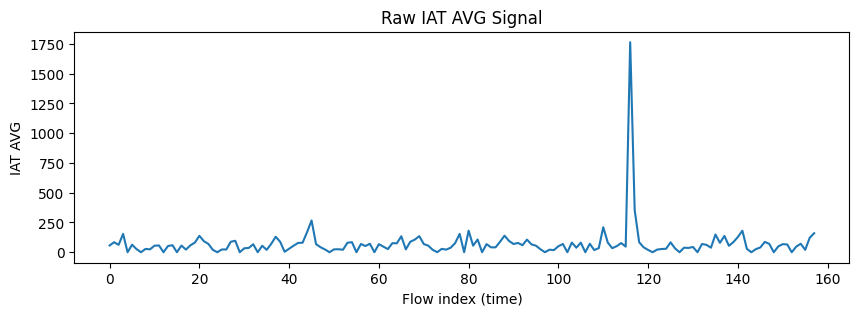

In [15]:
plt.figure(figsize=(10, 3))
plt.plot(iat_signal)
plt.title("Raw IAT AVG Signal")
plt.xlabel("Flow index (time)")
plt.ylabel("IAT AVG")
plt.show()

In [16]:
df["Attack"].value_counts()

Attack
Benign            2237731
Exploits            42748
Fuzzers             33816
Generic             19651
Reconnaissance      17074
DoS                  5980
Backdoor             4659
Shellcode            2381
Analysis             1226
Worms                 158
Name: count, dtype: int64

## Standardise the signal

In [17]:
iat_signal = (iat_signal - np.mean(iat_signal)) / np.std(iat_signal)

In [18]:
scales = np.arange(1, 128) 

## Apply CWT

In [19]:
coefficients, frequencies = pywt.cwt(iat_signal, scales, wavelet_name)

## Plot scalogram

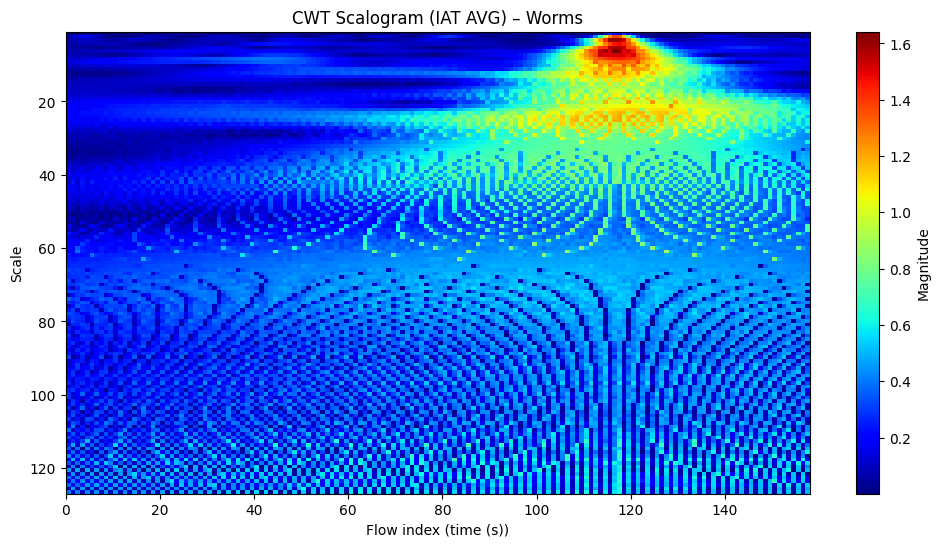

In [ ]:
plt.figure(figsize=(12, 6))

plt.imshow(
    np.abs(coefficients),
    aspect='auto',
    cmap='jet',
    extent=[0, len(iat_signal), scales[-1], scales[0]]
)

plt.colorbar(label='Magnitude')
plt.xlabel('Flow index (time (s))')
plt.ylabel('Scale')
plt.title(f'CWT Scalogram (IAT AVG) – {attack_type}')
plt.show()

## Compute for remaining attack types

In [21]:
max_samples = 2000

In [22]:
attack_types = [x for x in df["Attack"].unique() if x != "Worms"]

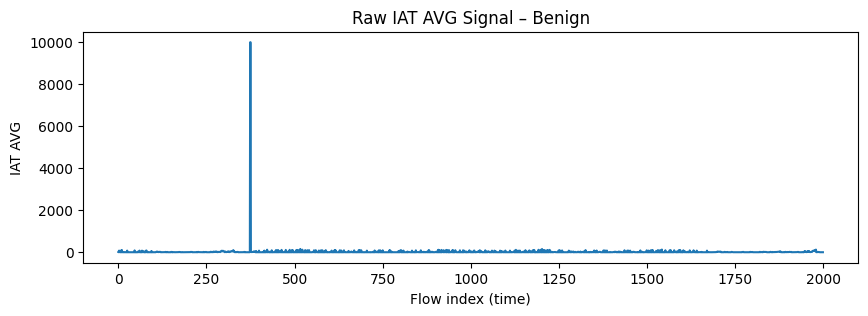

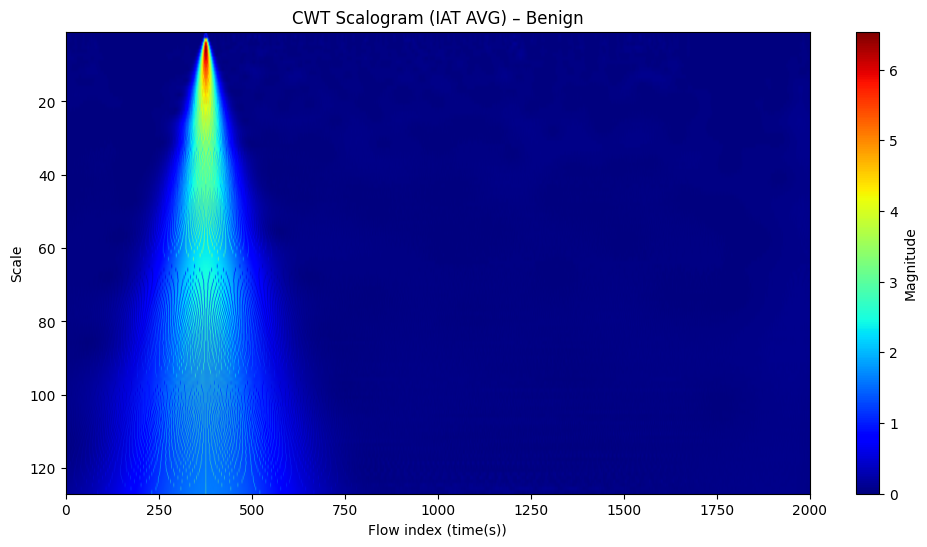

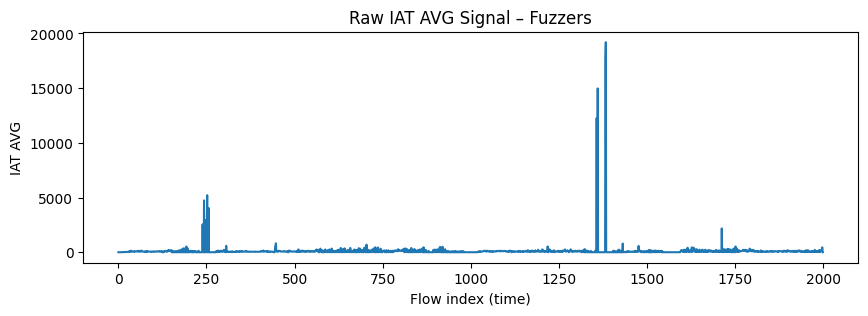

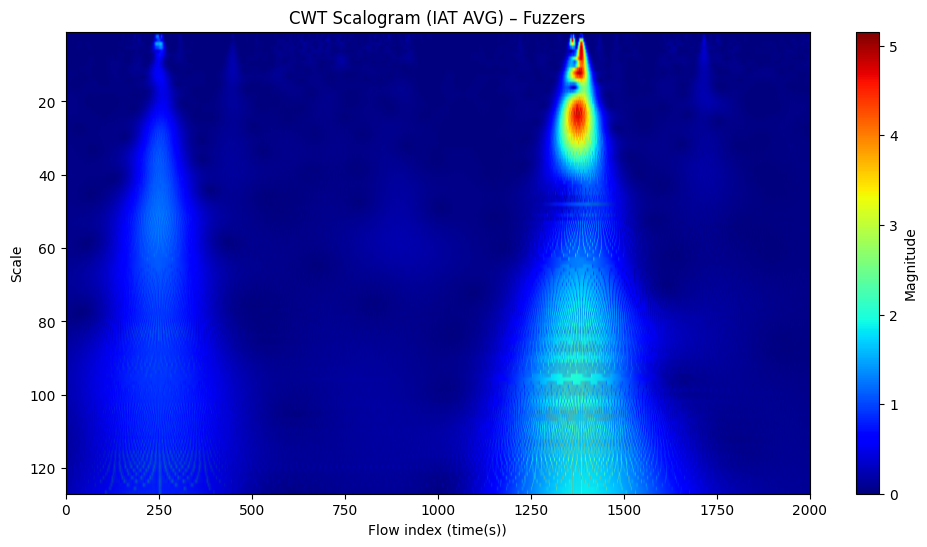

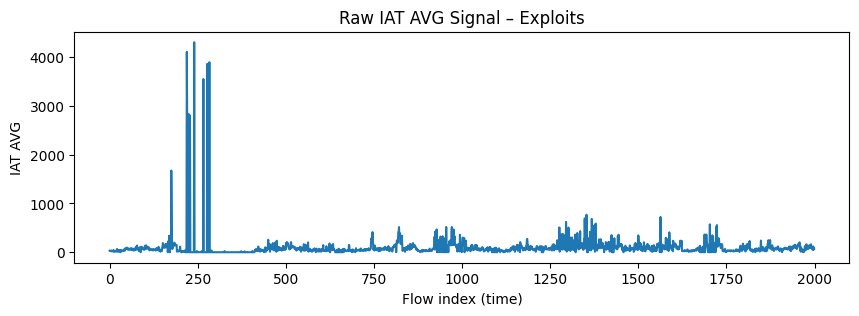

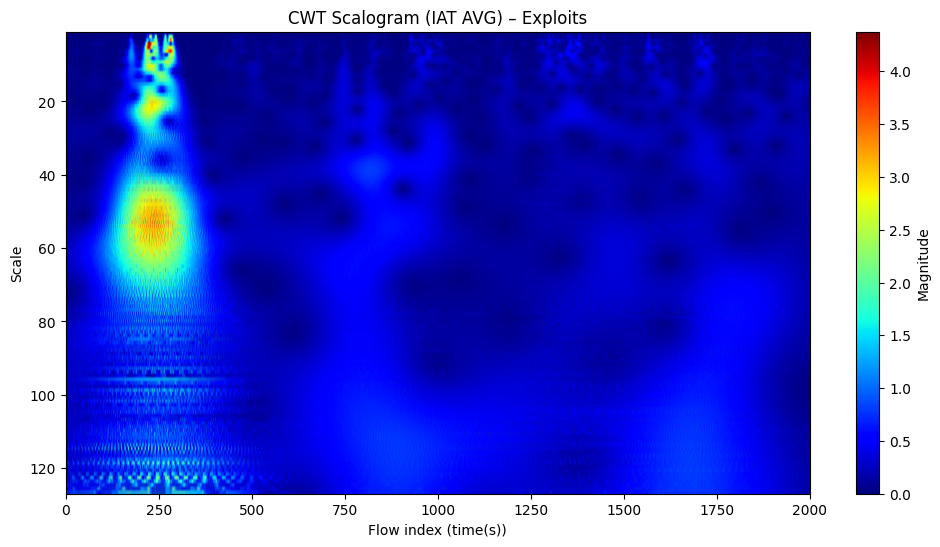

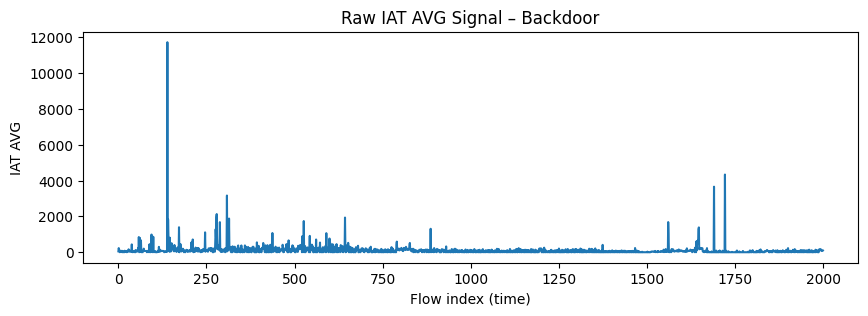

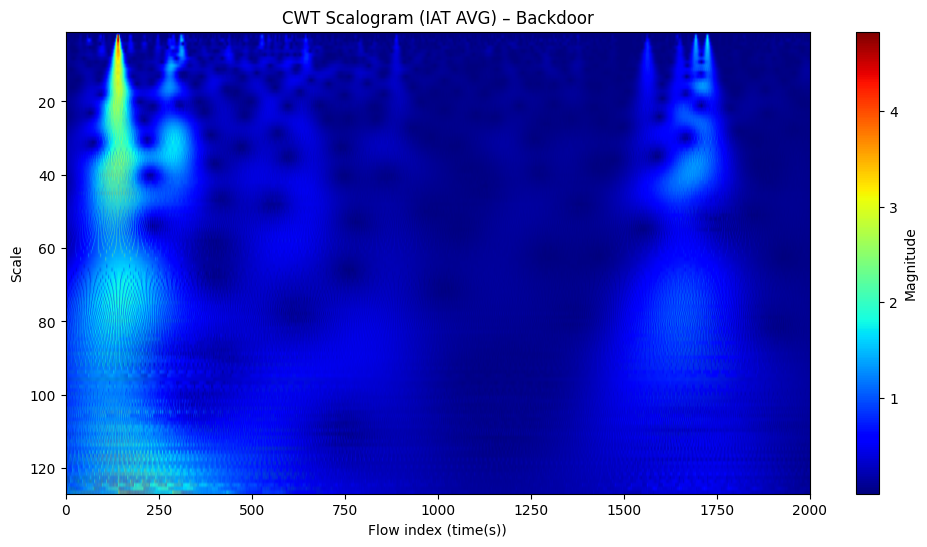

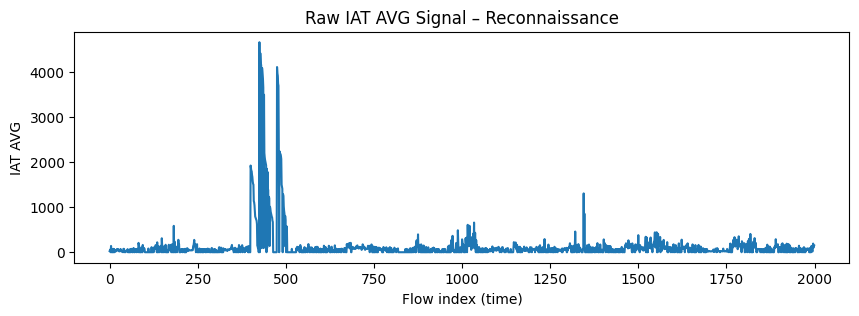

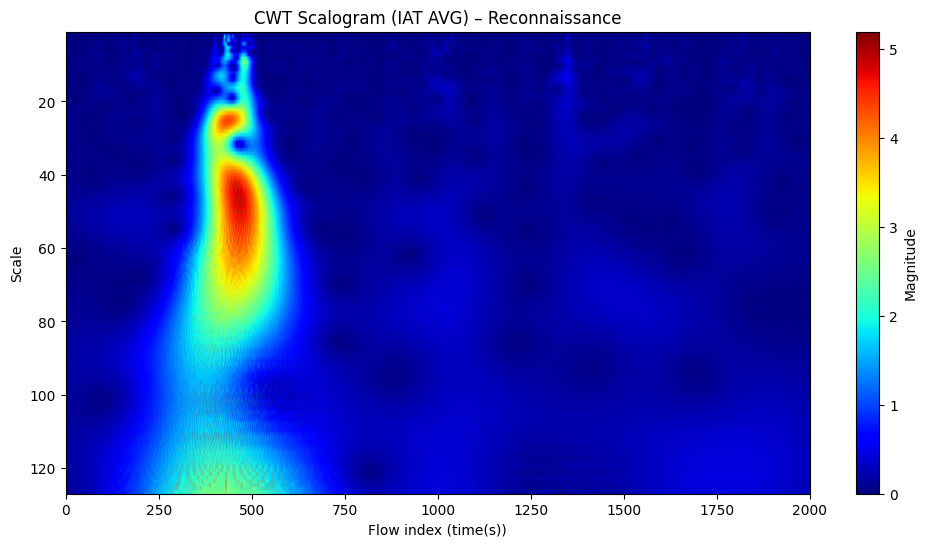

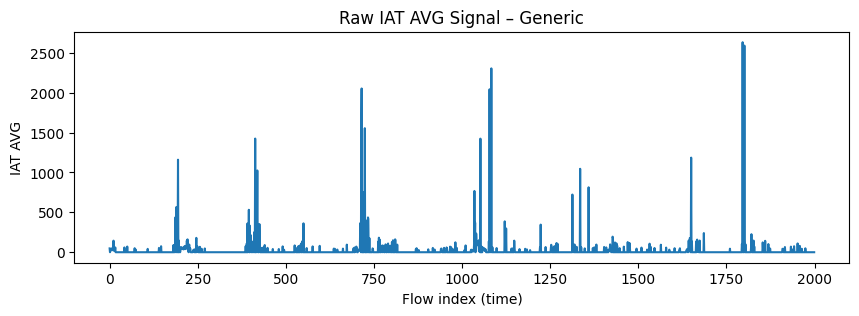

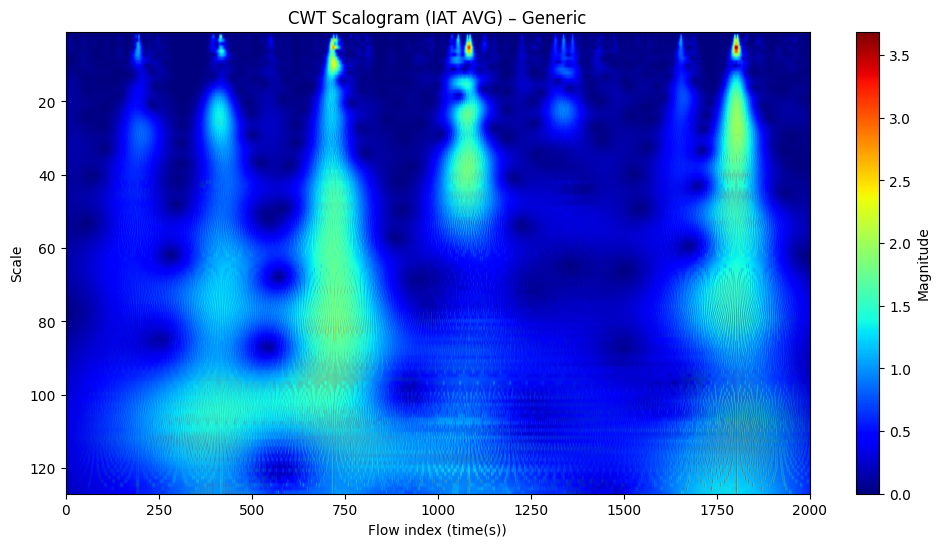

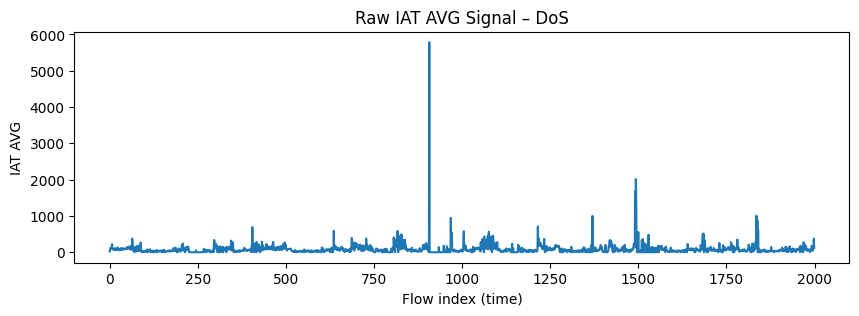

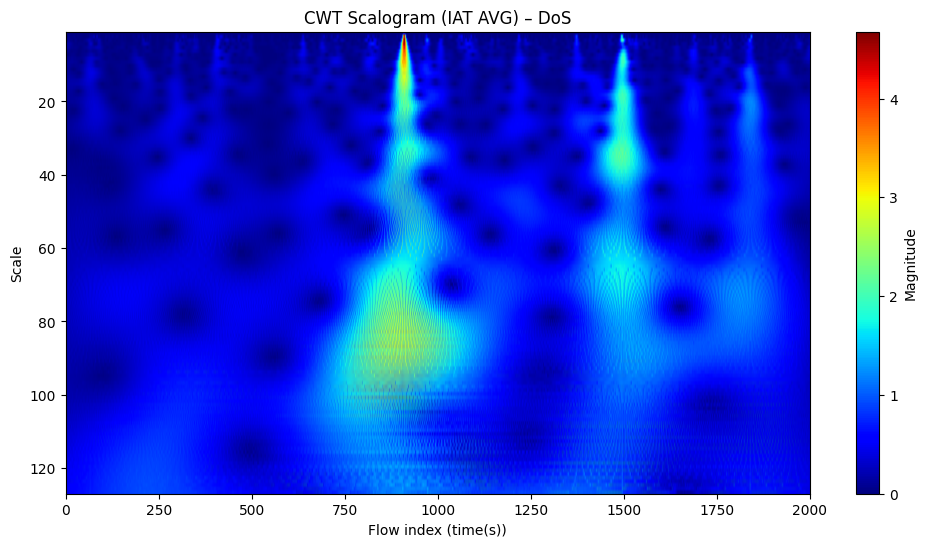

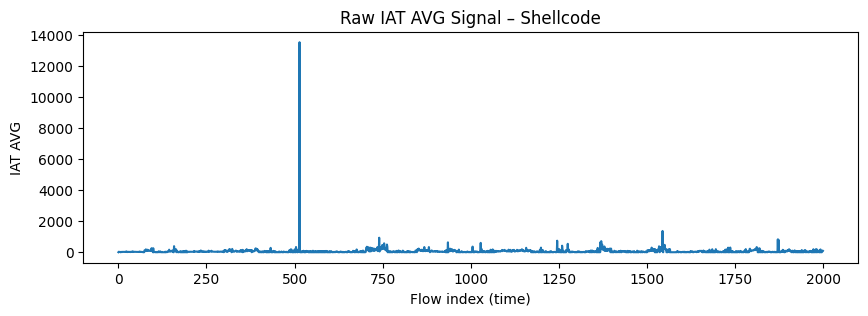

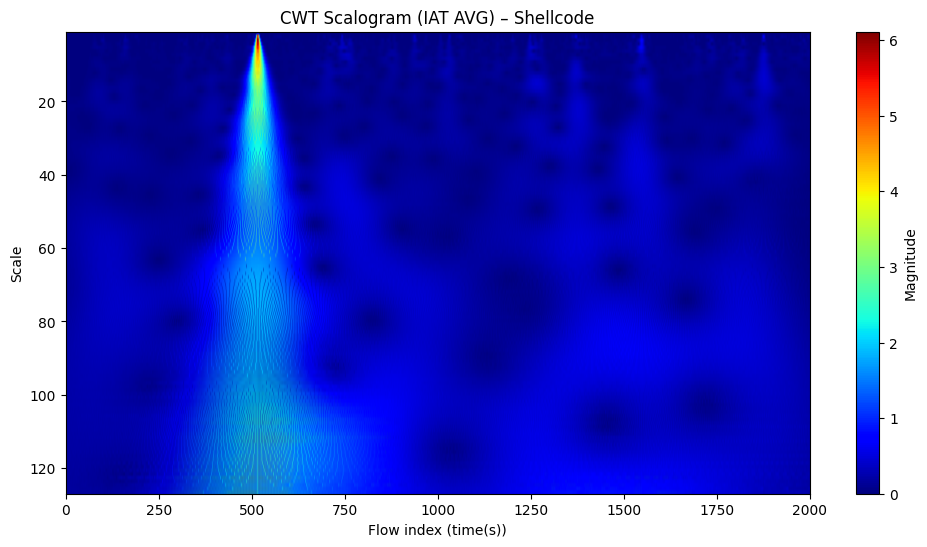

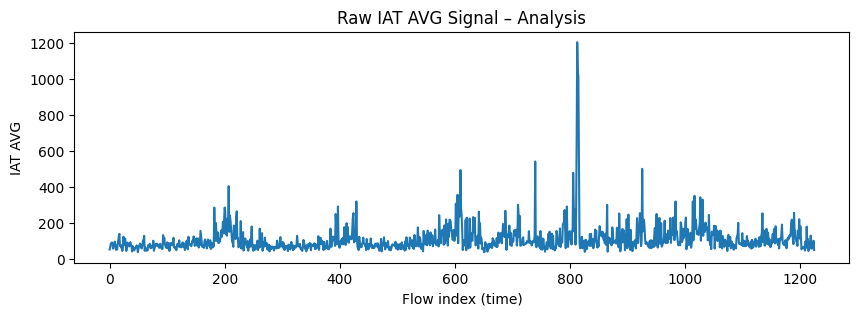

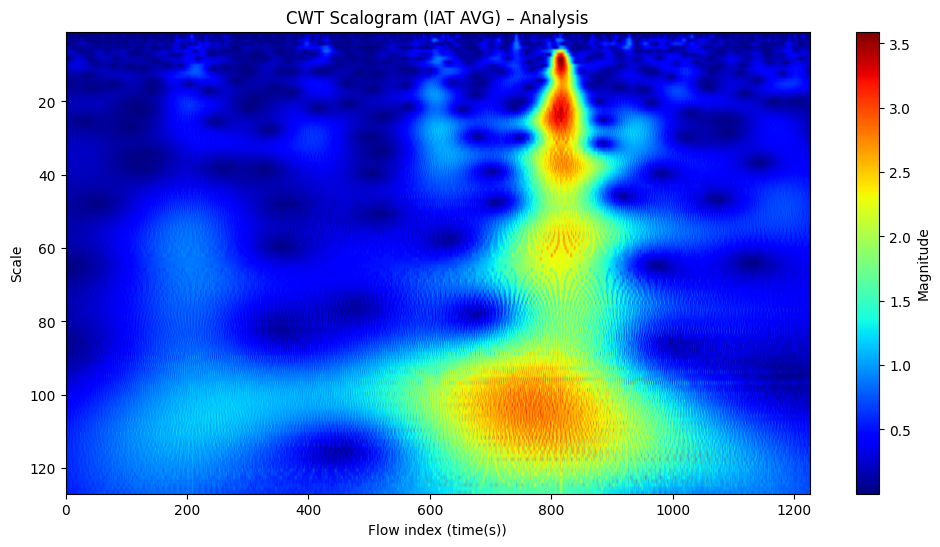

In [23]:
for attack_type in attack_types:
    df_attack = df[df["Attack"] == attack_type]
    
    n_samples = min(len(df_attack), max_samples)
    df_attack = df_attack.iloc[:n_samples]
    
    df_attack = df_attack.sort_values(by="FLOW_START_MILLISECONDS")
    
    iat_signal = df_attack["SRC_TO_DST_IAT_AVG"]
    iat_signal = iat_signal.replace([np.inf, -np.inf], np.nan)
    iat_signal = iat_signal.dropna()
    iat_signal = iat_signal.values
    
    plt.figure(figsize=(10, 3))
    plt.plot(iat_signal)
    plt.title(f"Raw IAT AVG Signal – {attack_type}")
    plt.xlabel("Flow index (time)")
    plt.ylabel("IAT AVG")
    plt.show()
    
    iat_signal = (iat_signal - np.mean(iat_signal)) / np.std(iat_signal)
    
    coefficients, frequencies = pywt.cwt(iat_signal, scales, wavelet_name)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(
        np.abs(coefficients),
        aspect='auto',
        cmap='jet',
        extent=[0, len(iat_signal), scales[-1], scales[0]]
    )
    plt.colorbar(label='Magnitude')
    plt.xlabel('Flow index (time(s))')
    plt.ylabel('Scale')
    plt.title(f'CWT Scalogram (IAT AVG) – {attack_type}')
    plt.show()